In [67]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np

from land_cover.load import plot_dir, loadGLAKES_GSWL, bawld_join_gswl_abz_filtered_pth, loadBAWLD, loadGreenness
from land_cover.plotting import reg_hexplot

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
gdf = loadGLAKES_GSWL(filter_matches=False, region="na_abz", force_reload=True)

Drop variables that need to be rec computed on the Grid scale

In [ ]:
gdf.drop(
    columns=[
        "occP1",
        "occP2",
        "occP3",
        "LEV_p1",
        "LEV_p2",
        "LEV_p3",
        "LEV_p13ain",
        "LEV_p13rin",
        "LEV_p23ain",
        "LEV_p23rin",
        "LEV_p13occ_ain",
        "LEV_p23occ_ain",
        "LEV_p13in",
    ],
    inplace=True,
)

In [69]:
gdf.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1549717 entries, 6 to 1878283
Data columns (total 85 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Lake_id_glakes        1549717 non-null  int64   
 1   Area_bound_glakes     1549717 non-null  float64 
 2   Area_PW_glakes        1549281 non-null  float64 
 3   Continent_glakes      1549717 non-null  object  
 4   Lat_glakes            1549717 non-null  float64 
 5   Lon_glakes            1549717 non-null  float64 
 6   GFed_flag_glakes      1549717 non-null  int64   
 7   PFed_flag_glakes      1549717 non-null  int64   
 8   Endo_flag_glakes      1549717 non-null  int64   
 9   Rser_flag_glakes      1549717 non-null  int64   
 10  Shape_Leng_glakes     1549717 non-null  float64 
 11  Shape_Area_glakes     1549717 non-null  float64 
 12  areaP1                331823 non-null   float64 
 13  areaP2                331823 non-null   float64 
 14  areaP3         

In [ ]:
# compare nulls to greenness FYI: should be fewer non-nulls because NA ABZ only
greennessx2 = loadGreenness()

In [5]:
greennessx2.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 68 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Lake_id_glakes        1878284 non-null  int64   
 1   Area_bound_glakes     1878284 non-null  float64 
 2   Area_PW_glakes        1877185 non-null  float64 
 3   Continent_glakes      1878284 non-null  object  
 4   Lat_glakes            1878284 non-null  float64 
 5   Lon_glakes            1878284 non-null  float64 
 6   GFed_flag_glakes      1878284 non-null  int64   
 7   PFed_flag_glakes      1878284 non-null  int64   
 8   Endo_flag_glakes      1878284 non-null  int64   
 9   Rser_flag_glakes      1878284 non-null  int64   
 10  Shape_Leng_glakes     1878284 non-null  float64 
 11  Shape_Area_glakes     1878284 non-null  float64 
 12  areaP1                542298 non-null   float64 
 13  areaP2                542944 non-null   float64 
 14  areaP3    

In [70]:
gdf.head()

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,Zmax_gswl,Zmean_gswl,q_gswl,KG_gswl,LGM_gswl,area_km2_gswl,dyn_ratio_gswl,depth_ratio_gswl,match_gswl,geometry
6,24,6987.727526,6408.023451,North America,53.549500,-63.992625,0,1,0,1,...,5.517913,2.419782,1.526856,27.0,ice,0.202558,0.185994,0.438532,0.0,"MULTIPOLYGON (((-66.48825 53.66875, -66.4885 5..."
10,40,4869.707306,4491.280258,North America,66.495447,-70.561392,0,1,0,0,...,4.250686,1.855246,1.279398,27.0,ice,0.109341,0.178234,0.436458,0.0,"MULTIPOLYGON (((-70.77548 66.92143, -70.77575 ..."
12,47,4445.288180,4307.917229,North America,49.823532,-88.517557,0,0,0,1,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-88.38025 50.2885, -88.3805 50..."
13,48,4362.538872,3844.535752,North America,54.042750,-69.254000,0,1,0,1,...,14.758257,5.384435,1.475450,27.0,ice,2.284907,0.280733,0.364842,0.0,"MULTIPOLYGON (((-69.4725 54.89075, -69.4725 54..."
15,57,3542.349852,3321.742907,North America,63.113516,-101.407247,0,1,0,0,...,4.776712,1.994000,1.237994,27.0,ice,0.020241,0.071350,0.417442,0.0,"MULTIPOLYGON (((-100.668 63.41525, -100.668 63..."


# Join BAWLD and aggregate over its grid cells

In [79]:
# Grid to BAWLD grid to plot prevelance rel to non-selected lakes
gdf_bawld = loadBAWLD()
gdf_bawld_for_join = gdf_bawld[["Cell_ID_bawld", "geometry"]]

In [81]:
gdf.columns

Index(['Lake_id_glakes', 'Area_bound_glakes', 'Area_PW_glakes',
       'Continent_glakes', 'Lat_glakes', 'Lon_glakes', 'GFed_flag_glakes',
       'PFed_flag_glakes', 'Endo_flag_glakes', 'Rser_flag_glakes',
       'Shape_Leng_glakes', 'Shape_Area_glakes', 'areaP1', 'areaP2', 'areaP3',
       'NDVI8499', 'NDVI0010', 'NDVI1121', 'vegeP1', 'validP1', 'vegeP2',
       'validP2', 'vegeP3', 'validP3', 'occP2', 'area_1984_1999_wm',
       'area_2000_2009_wm', 'area_2010_2019_wm', 'max_bound_dist',
       'mean_bound_dist', 'Hylak_id', 'Lake_name_hylak', 'Country_hylak',
       'Continent_hylak', 'Poly_src_hylak', 'Lake_type_hylak',
       'Grand_id_hylak', 'Lake_area_hylak', 'Shore_len_hylak',
       'Shore_dev_hylak', 'Vol_total_hylak', 'Vol_res_hylak', 'Vol_src_hylak',
       'Depth_avg_hylak', 'Dis_avg_hylak', 'Res_time_hylak', 'Elevation_hylak',
       'Slope_100_hylak', 'Wshd_area_hylak', 'Pour_long_hylak',
       'Pour_lat_hylak', 'sen_slope', 'mann_kendall_trend',
       'trend_signific

In [73]:
gdf_bawld.columns

Index(['Area_km2', 'Temp_K', 'LEV_MEAN_km2_k23', 'LEV_MIN_km', 'LEV_MAX_km',
       'est_mg_m2_day_k23', 'est_g_day_k23', 'lake_count_k23',
       'LEV_MEAN_frac_k23', 'LEV_MIN_frac_k23', 'LEV_MAX_frac_k23',
       'Cell_ID_bawld', 'Long_bawld', 'Lat_bawld', 'Area_Pct_bawld',
       'Shp_Area_bawld', 'GLA', 'ROC', 'TUN', 'BOR', 'WET', 'PEB', 'WTU',
       'MAR', 'BOG', 'FEN', 'LAK', 'LAL', 'MPL', 'MYL', 'MGL', 'SPL', 'SYL',
       'SGL', 'RIV', 'LAR', 'SRR', 'SRP', 'GLA_L', 'GLA_H', 'ROC_L', 'ROC_H',
       'TUN_L', 'TUN_H', 'BOR_L', 'BOR_H', 'WET_L', 'WET_H', 'PEB_L', 'PEB_H',
       'WTU_L', 'WTU_H', 'MAR_L', 'MAR_H', 'BOG_L', 'BOG_H', 'FEN_L', 'FEN_H',
       'LAK_L', 'LAK_H', 'LAL_L', 'LAL_H', 'MPL_L', 'MPL_H', 'MYL_L', 'MYL_H',
       'MGL_L', 'MGL_H', 'SPL_L', 'SPL_H', 'SYL_L', 'SYL_H', 'SGL_L', 'SGL_H',
       'RIV_L', 'RIV_H', 'LAR_L', 'LAR_H', 'SRR_L', 'SRR_H', 'SRP_L', 'SRP_H',
       'WETSCAPE', 'LEV_MEAN_grid_frac_k23', 'LEV_MIN_grid_frac_k23',
       'LEV_MAX_grid_frac_k23

In [82]:
# temp dataset for join
_gdf_points = (
    gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf["Lon_glakes"], gdf["Lat_glakes"]),
        crs=gdf.crs,
    )
    .drop(columns=["index_right"])
    .to_crs(gdf_bawld.crs)
)

<Axes: >

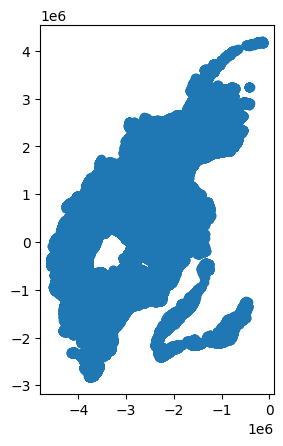

In [11]:
_gdf_points.plot()

In [87]:
# aggregate
gdf_joined = gpd.sjoin(gdf_bawld_for_join, _gdf_points, how="left", predicate="contains")

In [88]:
gdf_joined.info(max_cols=500, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1565358 entries, 0 to 23468
Data columns (total 74 columns):
 #   Column                Non-Null Count    Dtype   
---  ------                --------------    -----   
 0   Cell_ID_bawld         1565358 non-null  int64   
 1   geometry              1565358 non-null  geometry
 2   index_right           1549693 non-null  float64 
 3   Lake_id_glakes        1549693 non-null  float64 
 4   Area_bound_glakes     1549693 non-null  float64 
 5   Area_PW_glakes        1549257 non-null  float64 
 6   Continent_glakes      1549693 non-null  object  
 7   Lat_glakes            1549693 non-null  float64 
 8   Lon_glakes            1549693 non-null  float64 
 9   GFed_flag_glakes      1549693 non-null  float64 
 10  PFed_flag_glakes      1549693 non-null  float64 
 11  Endo_flag_glakes      1549693 non-null  float64 
 12  Rser_flag_glakes      1549693 non-null  float64 
 13  Shape_Leng_glakes     1549693 non-null  float64 
 14  Shape_Area_glakes

Aggregate

In [89]:
# slow version to ensure nanmean
from pandas.api.types import is_float_dtype
gdf_sjoin = gpd.sjoin(gdf_bawld_for_join, _gdf_points, how="left", predicate="contains")

def my_nanmean(s):
    return np.nanmean(s)

# future numpy: just use function np.nanmean
agg_map = {
    col: (my_nanmean if is_float_dtype(gdf_sjoin[col]) else "first") for col in gdf_sjoin.columns
}
agg_map["geometry"] = "first"  # ensure geometry isn't sent to np dtypes
sum_vars = [
    "areaP1",
    "areaP2",
    "areaP3",
    "area_1984_1999_wm",
    "area_2000_2009_wm",
    "area_2010_2019_wm",
    "vegeP1",
    "validP1",
    "vegeP2",
    "validP2",
    "vegeP3",
    "validP3",
]
for col in sum_vars:
    agg_map[col] = "sum"

gdf_regridded = gdf_sjoin.groupby("Cell_ID_bawld", as_index=False).agg(agg_map)
gdf_regridded = gdf_regridded.merge(
    gdf_bawld.drop(columns="geometry"), on="Cell_ID_bawld"
)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_20023/1390794141.py:6: RuntimeWarning: Mean of empty slice
  return np.nanmean(s)


In [64]:
gdf_regridded.area_1984_1999_wm.describe()

count    23469.000000
mean        24.262027
std        106.382767
min          0.000000
25%          0.000000
50%          0.000000
75%          1.488721
max       6597.647876
Name: area_1984_1999_wm, dtype: float64

In [99]:
# compute LEV on grid cells
area_vars = [
    "area_1984_1999_wm",
    "area_2000_2009_wm",
    "area_2010_2019_wm",
]
for i, n in enumerate([1,2,3]):
    gdf_regridded[f"AV_per_p{n}_liu_regrid"] = gdf_regridded[f"areaP{n}"] / gdf_regridded.Shp_Area_bawld * 1e9 * 100
    gdf_regridded[f"LEV_p{n}_liu_regrid"] = (
        gdf_regridded[f"areaP{n}"] / gdf_regridded[area_vars[i]] * 100
    )

# MA over time
gdf_regridded["LEV_change_p1p2_liu_regrid"] = (
    gdf_regridded["LEV_p2_liu_regrid"] - gdf_regridded["LEV_p1_liu_regrid"]
)
gdf_regridded["LEV_change_p1p3_liu_regrid"] = (
    gdf_regridded["LEV_p3_liu_regrid"] - gdf_regridded["LEV_p1_liu_regrid"]
)
gdf_regridded["LEV_change_p2p3_liu_regrid"] = (
    gdf_regridded["LEV_p3_liu_regrid"] - gdf_regridded["LEV_p2_liu_regrid"]
)

In [98]:
# Compute Occ
veg_observation_vars = [
    "vegeP1",
    "vegeP2",
    "vegeP3",
]
valid_observation_vars = [
    "validP1",
    "validP2",
    "validP3",
]
for i, n in enumerate([1,2,3]):
    gdf_regridded[f"AV_Occ_p{n}_liu_regrid"] = (
        gdf_regridded[f"vegeP{n}"] / gdf_regridded[f"validP{n}"] * 100
    )

# Change in occ over time
gdf_regridded["AV_Occ_change_p1p2_liu_regrid"] = (
    gdf_regridded["AV_Occ_p2_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
)
gdf_regridded["AV_Occ_change_p1p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p1_liu_regrid"]
)
gdf_regridded["AV_Occ_change_p2p3_liu_regrid"] = (
    gdf_regridded["AV_Occ_p3_liu_regrid"] - gdf_regridded["AV_Occ_p2_liu_regrid"]
)

In [103]:
# Compute NDVI change (simple avg)

gdf_regridded["NDVI_p1p2_liu_regrid"] = (
    gdf_regridded["NDVI0010"] - gdf_regridded["NDVI8499"]
)
gdf_regridded["NDVI_p1p3_liu_regrid"] = (
    gdf_regridded["NDVI1121"] - gdf_regridded["NDVI8499"]
)
gdf_regridded["NDVI_p2p3_liu_regrid"] = (
    gdf_regridded["NDVI1121"] - gdf_regridded["NDVI0010"]
)

In [104]:
gdf_regridded.info(max_cols=500, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23469 entries, 0 to 23468
Data columns (total 177 columns):
 #    Column                         Non-Null Count  Dtype   
---   ------                         --------------  -----   
 0    Cell_ID_bawld                  23469 non-null  int64   
 1    geometry                       23469 non-null  geometry
 2    index_right                    7804 non-null   float64 
 3    Lake_id_glakes                 7804 non-null   float64 
 4    Area_bound_glakes              7804 non-null   float64 
 5    Area_PW_glakes                 7800 non-null   float64 
 6    Continent_glakes               7804 non-null   object  
 7    Lat_glakes                     7804 non-null   float64 
 8    Lon_glakes                     7804 non-null   float64 
 9    GFed_flag_glakes               7804 non-null   float64 
 10   PFed_flag_glakes               7804 non-null   float64 
 11   Endo_flag_glakes               7804 non-null   float64 
 12   Rser_flag_glakes

<Axes: >

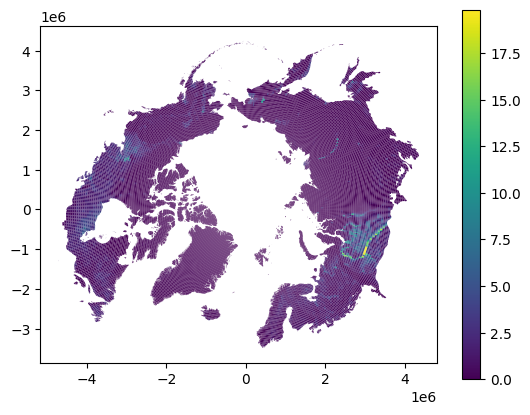

In [53]:
gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).plot(
    column="MAR", legend=True
)

<Axes: >

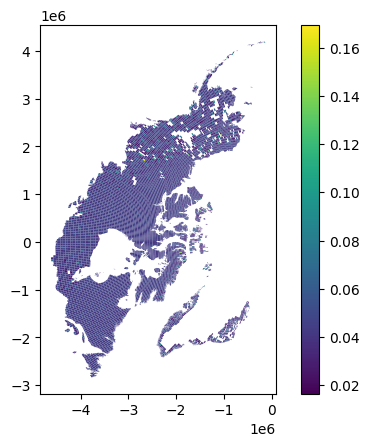

In [101]:
gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).plot(
    column="b2_mean", legend=True, edgecolor=None
)

NDVI is increasing (simple avg)

<Axes: >

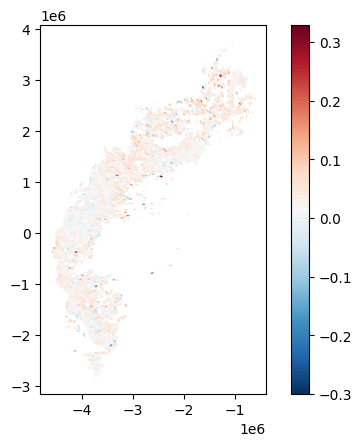

In [115]:
gpd.GeoDataFrame(
    gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs
).plot(column="NDVI_p2p3_liu_regrid", legend=True, edgecolor=None, cmap="RdBu_r")

Masked to NA, still increasing, just note color bar shift

<Axes: >

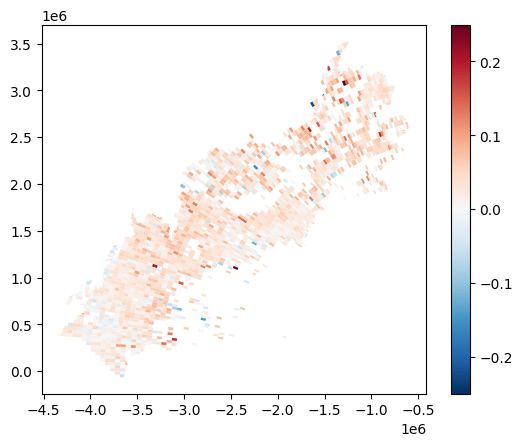

In [124]:
gpd.GeoDataFrame(
    gdf_regridded[np.isfinite(gdf_regridded.sen_slope)],
    geometry=gdf_regridded.geometry,
    crs=gdf_bawld.crs,
).plot(column="NDVI_p2p3_liu_regrid", legend=True, edgecolor=None, cmap="RdBu_r", vmin=-0.25, vmax=0.25)

<Axes: ylabel='Frequency'>

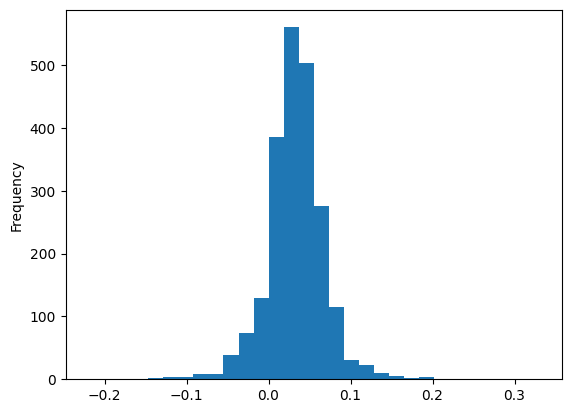

In [119]:
gdf_regridded[np.isfinite(gdf_regridded.sen_slope)].NDVI_p2p3_liu_regrid.plot.hist(bins=30)

Greenness is decreasing (simple avg, unequal aggregation first to GLAKES)

<Axes: >

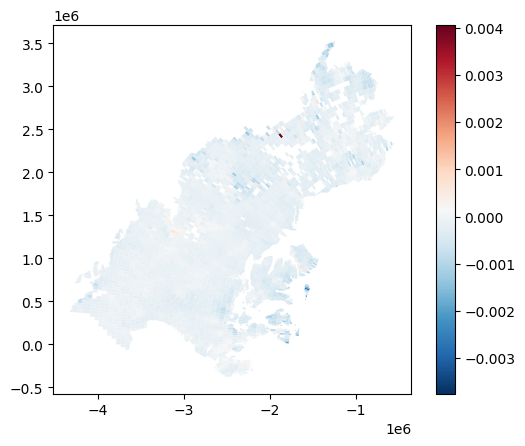

In [109]:
gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).plot(
    column="sen_slope", legend=True, edgecolor=None, cmap="RdBu_r"
)

<Axes: ylabel='Frequency'>

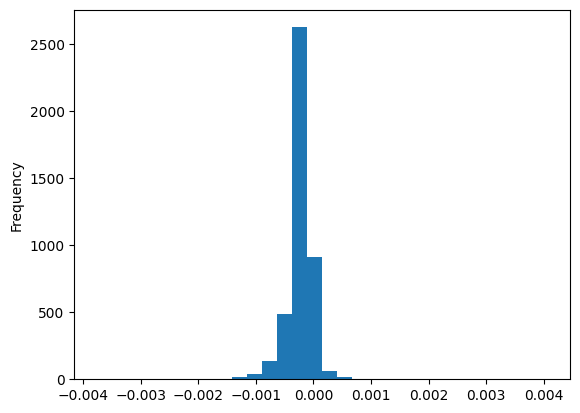

In [120]:
gdf_regridded.sen_slope.plot.hist(bins=30)

<Axes: >

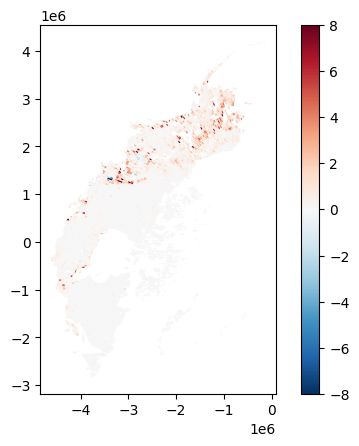

In [122]:
gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).plot(
    column="AV_Occ_change_p2p3_liu_regrid", legend=True, edgecolor=None, cmap="RdBu_r", vmin=-8, vmax=8
)

Now, manually add weighted mean LEV

In [10]:
_gdf_points["Area_PWxLEV_p3"] = _gdf_points["Area_PW"] * _gdf_points["LEV_p3"]
gdf_regridded_weight_mean_groupby = gpd.sjoin(gdf_bawld, _gdf_points, how="left", predicate="contains").groupby("Cell_ID")

In [11]:
def my_nansum(s):
    return np.nansum(s)


numerator = gdf_regridded_weight_mean_groupby.Area_PWxLEV_p3.agg(my_nansum)
denominator = gdf_regridded_weight_mean_groupby.Area_PW.agg(my_nansum)
gdf_regridded["LEV_p3_weighted"] = denominator

In [41]:
_gdf_points["Area_PWxLEV_p3"]
_gdf_points["Area_PW"]
# gdf_regridded["LEV_p3_weighted"]

6          6408.023451
10         4491.280258
12         4307.917229
13         3844.535752
15         3321.742907
              ...     
1878278       0.025014
1878279       0.023372
1878281       0.025493
1878282       0.021101
1878283       0.024481
Name: Area_PW, Length: 1549717, dtype: float64

In [34]:
denominator.describe()

count    23469.000000
mean        24.288062
std        104.474071
min          0.000000
25%          0.000000
50%          0.000000
75%          2.965643
max       6510.704969
Name: Area_PW, dtype: float64

In [12]:
gdf_regridded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23469 entries, 0 to 23468
Columns: 163 entries, Area_km2 to LEV_p3_weighted
dtypes: float64(153), geometry(1), int64(3), object(6)
memory usage: 29.2+ MB


In [13]:
gdf_regridded.head()

,Area_km2,Temp_K,LEV_MEAN_k,LEV_MIN_km,LEV_MAX_km,d_counting,est_mg_m2_,est_g_day,lake_count,LEV_MEAN_f,...,Zmean_gswl,q_gswl,area_gswl,KG_gswl,LGM_gswl,area_km2_gswl,match_gswl,dyn_ratio_gswl,depth_ratio_gswl,LEV_p3_weighted
0,6.03,279.286143,0.727184,0.255664,1.710332,1.703681,7.685994,46346.545638,7.0,0.120594,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
4,0.48,275.980649,0.034568,0.010126,0.092836,0.067926,7.028025,3373.452130,2.0,0.072017,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN


In [125]:
bawld_join_gswl_abz_filtered_pth

PosixPath('/Volumes/metis/ABOVE3/other_outputs/BAWLD_GLAKES_gswl_filtered.gpkg')

In [126]:
# export to QGIS
gpd.GeoDataFrame(gdf_regridded, geometry=gdf_regridded.geometry, crs=gdf_bawld.crs).to_file(bawld_join_gswl_abz_filtered_pth)

How does my LEV estimate compare to Liu 2025?

In [17]:
gdf_regridded_cp = gdf_regridded.copy()

In [21]:
# clip LEV_p1, LEV_p2, LEV_p3 to [0, 100]
# more not needed thanks to code that computes extents below
cols = ["LEV_p1", "LEV_p2", "LEV_p3", "LEV_p3_weighted"]
gdf_regridded_cp[cols] = gdf_regridded_cp[cols].clip(0, 100)

In [22]:
# rm outliers for plotting ease
for col in ["LEV_p13ain", "LEV_p13rin"]:
    low, high = gdf_regridded_cp[col].quantile([0.02, 0.98])
    gdf_regridded_cp.loc[(gdf[col] < low) | (gdf_regridded_cp[col] > high), col] = np.nan

<Axes: xlabel='LEV_MEAN_f', ylabel='LEV_p3_weighted'>

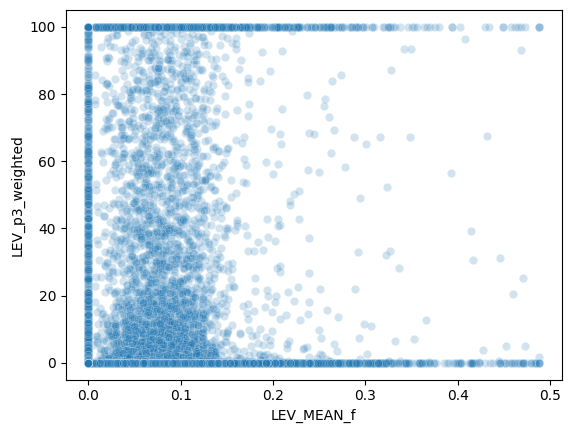

In [23]:
sns.scatterplot(gdf_regridded_cp, x="LEV_MEAN_f", y="LEV_p3_weighted", alpha=0.2)

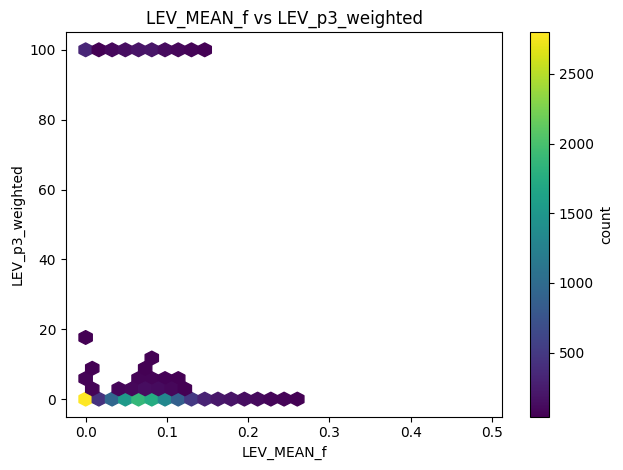

In [27]:
reg_hexplot(gdf_regridded_cp, xvar="LEV_MEAN_f", yvar="LEV_p3_weighted")

Error somewhere...